In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import iirnotch, filtfilt, butter
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from pathlib import Path

In [2]:
data = pd.read_csv(r"D:\eeg-analysis\eeg-analysis\cognitive_state_discrimination_dataset - cognitive_state_discrimination_dataset.csv")
data.columns = data.columns.str.strip()
print(data)
print(data.columns)

    Participant_ID                        Task  Channel_1_PSD  Channel_2_PSD  \
0                1               Resting State       0.497405       0.952911   
1                1               Memory Recall       0.465067       0.275623   
2                1      Arithmetic Calculation       0.533103       0.592343   
3                1  Visual Pattern Recognition       0.535369       0.038921   
4                2               Resting State       0.388730       0.541622   
5                2               Memory Recall       0.042516       0.700915   
6                2      Arithmetic Calculation       0.203603       0.730799   
7                2  Visual Pattern Recognition       0.728872       0.374454   
8                3               Resting State       0.805906       0.080747   
9                3               Memory Recall       0.655675       0.433524   
10               3      Arithmetic Calculation       0.896095       0.629961   
11               3  Visual Pattern Recog

In [3]:
kolom_nan = ['ERP_Memory_Recall', 'ERP_Arithmetic', 'ERP_Visual_Pattern']

data_bersih = data.drop(columns=kolom_nan)

print("--- Info Data Setelah Bersih dari NaN ---")
data_bersih.info()

print("\n--- Data Head ---")
print(data_bersih.head())

--- Info Data Setelah Bersih dari NaN ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 68 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Participant_ID  40 non-null     int64  
 1   Task            40 non-null     object 
 2   Channel_1_PSD   40 non-null     float64
 3   Channel_2_PSD   40 non-null     float64
 4   Channel_3_PSD   40 non-null     float64
 5   Channel_4_PSD   40 non-null     float64
 6   Channel_5_PSD   40 non-null     float64
 7   Channel_6_PSD   40 non-null     float64
 8   Channel_7_PSD   40 non-null     float64
 9   Channel_8_PSD   40 non-null     float64
 10  Channel_9_PSD   40 non-null     float64
 11  Channel_10_PSD  40 non-null     float64
 12  Channel_11_PSD  40 non-null     float64
 13  Channel_12_PSD  40 non-null     float64
 14  Channel_13_PSD  40 non-null     float64
 15  Channel_14_PSD  40 non-null     float64
 16  Channel_15_PSD  40 non-null     float64


In [4]:
# 'y' adalah apa yang ingin kita prediksi
y = data_bersih['Target_Label']

# 'X' adalah semua kolom lain yang kita gunakan untuk memprediksi
X = data_bersih.drop(columns=['Target_Label'])

print("Data X (fitur) sebelum diubah:")
print(X.head())

print("\nData y (target):")
print(y.head())

Data X (fitur) sebelum diubah:
   Participant_ID                        Task  Channel_1_PSD  Channel_2_PSD  \
0               1               Resting State       0.497405       0.952911   
1               1               Memory Recall       0.465067       0.275623   
2               1      Arithmetic Calculation       0.533103       0.592343   
3               1  Visual Pattern Recognition       0.535369       0.038921   
4               2               Resting State       0.388730       0.541622   

   Channel_3_PSD  Channel_4_PSD  Channel_5_PSD  Channel_6_PSD  Channel_7_PSD  \
0       0.376679       0.867884       0.241254       0.353079       0.517339   
1       0.785774       0.128620       0.723935       0.049756       0.230252   
2       0.551308       0.469252       0.286355       0.580777       0.471439   
3       0.210236       0.060953       0.178834       0.227446       0.056417   
4       0.458615       0.606508       0.417763       0.524841       0.204859   

   Channel_8_

In [5]:
print(y)

0     0
1     1
2     2
3     3
4     0
5     1
6     2
7     3
8     0
9     1
10    2
11    3
12    0
13    1
14    2
15    3
16    0
17    1
18    2
19    3
20    0
21    1
22    2
23    3
24    0
25    1
26    2
27    3
28    0
29    1
30    2
31    3
32    0
33    1
34    2
35    3
36    0
37    1
38    2
39    3
Name: Target_Label, dtype: int64


In [6]:
# Terapkan One-Hot Encoding pada kolom 'Task'
X_encoded = pd.get_dummies(X, columns=['Task'])

print("--- Data Info (Setelah 'Task' Di-encode) ---")
# Anda akan lihat ada kolom baru: Task_Resting State, Task_Memory Recall, dll.
X_encoded.info()

--- Data Info (Setelah 'Task' Di-encode) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 70 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Participant_ID                   40 non-null     int64  
 1   Channel_1_PSD                    40 non-null     float64
 2   Channel_2_PSD                    40 non-null     float64
 3   Channel_3_PSD                    40 non-null     float64
 4   Channel_4_PSD                    40 non-null     float64
 5   Channel_5_PSD                    40 non-null     float64
 6   Channel_6_PSD                    40 non-null     float64
 7   Channel_7_PSD                    40 non-null     float64
 8   Channel_8_PSD                    40 non-null     float64
 9   Channel_9_PSD                    40 non-null     float64
 10  Channel_10_PSD                   40 non-null     float64
 11  Channel_11_PSD                   40 non-n

In [7]:
# 1. Tentukan kolom mana saja yang perlu di-scale
# (Yaitu semua kolom yang bertipe angka)
kolom_untuk_scale = X_encoded.select_dtypes(include='number').columns

# 2. Buat scaler-nya
scaler = StandardScaler()

# 3. Terapkan scaler ke data X
X_scaled = X_encoded.copy() # Buat salinan
X_scaled[kolom_untuk_scale] = scaler.fit_transform(X_scaled[kolom_untuk_scale])

print("\n--- Data Head (Setelah Scaling) ---")
print(X_scaled.head())


--- Data Head (Setelah Scaling) ---
   Participant_ID  Channel_1_PSD  Channel_2_PSD  Channel_3_PSD  Channel_4_PSD  \
0       -1.566699      -0.122976       1.804502      -0.251639       1.489729   
1       -1.566699      -0.229293      -0.561184       1.295893      -1.137609   
2       -1.566699      -0.005611       0.545082       0.408950       0.072995   
3       -1.566699       0.001839      -1.387955      -0.881265      -1.378098   
4       -1.218544      -0.480267       0.367919       0.058311       0.560800   

   Channel_5_PSD  Channel_6_PSD  Channel_7_PSD  Channel_8_PSD  Channel_9_PSD  \
0      -0.908600      -0.520676       0.071153      -0.446630      -1.305356   
1       0.822939      -1.499368      -0.985127      -0.364478       0.976742   
2      -0.746810       0.214005      -0.097729      -1.380941       0.544890   
3      -1.132524      -0.926038      -1.624715      -0.907735       0.822295   
4      -0.275404       0.033523      -1.078552      -1.978117      -0.429458

In [8]:
# Import 'train_test_split' jika Anda belum (jika Sel [1] lupa dijalankan)
from sklearn.model_selection import train_test_split

# 'X_scaled' adalah fitur Anda yang sudah siap
# 'y' adalah target Anda (dari Sel [3])

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, 
                                                    test_size=0.2,    # 20% data untuk testing
                                                    random_state=42,  # Agar hasil 'acak'-nya selalu sama
                                                    stratify=y)       # Memastikan proporsi label seimbang

print("--- Data Berhasil Dibagi ---")
print(f"Jumlah data Latih (Train): {X_train.shape[0]} baris")
print(f"Jumlah data Tes (Test):   {X_test.shape[0]} baris")

--- Data Berhasil Dibagi ---
Jumlah data Latih (Train): 32 baris
Jumlah data Tes (Test):   8 baris


Plot line chart 'psd_line_chart.png' berhasil disimpan.


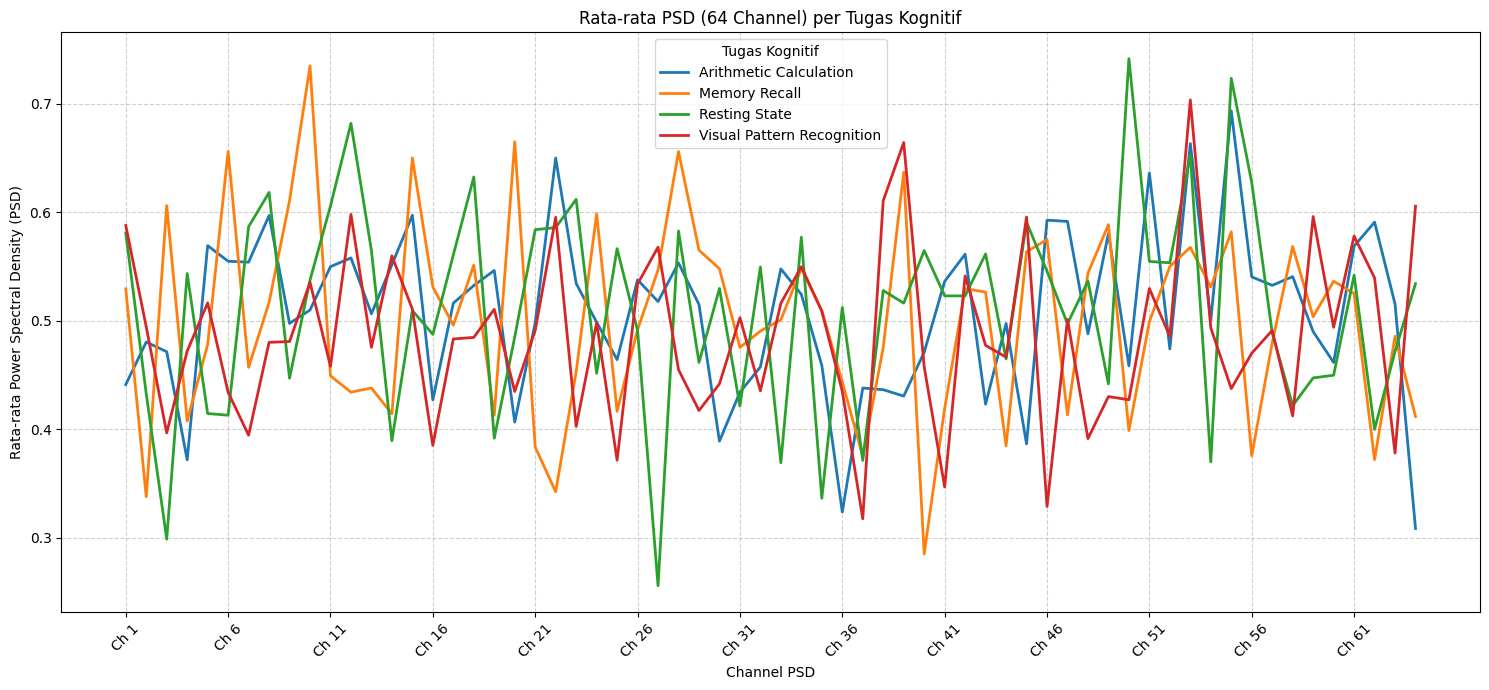

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

# (Ini berasumsi 'data_bersih' sudah ada dari Sel [2])
try:
    # 1. Pilih hanya kolom 'Task' dan kolom-kolom PSD
    psd_columns = [col for col in data_bersih.columns if 'PSD' in col]
    plot_data = data_bersih[['Task'] + psd_columns]

    # 2. Hitung rata-rata semua kolom PSD, dikelompokkan berdasarkan 'Task'
    avg_psd_by_task = plot_data.groupby('Task').mean()

    # 3. Buat plot
    plt.figure(figsize=(15, 7))
    
    # Kita Transpose (T) DataFrame agar Task menjadi garis, dan Channel menjadi sumbu X
    # 'ax=plt.gca()' dipakai agar plotnya menggunakan ukuran figure (figsize) yang kita set
    avg_psd_by_task.T.plot(ax=plt.gca(), linewidth=2)
    
    plt.title('Rata-rata PSD (64 Channel) per Tugas Kognitif')
    plt.xlabel('Channel PSD')
    plt.ylabel('Rata-rata Power Spectral Density (PSD)')
    
    # 4. Merapikan Sumbu X (karena 64 label channel terlalu banyak)
    # Kita hanya akan menampilkan label setiap 5 channel
    ticks_to_show = list(range(0, 64, 5)) # Tampilkan tick di channel 0, 5, 10...
    labels = [f'Ch {i+1}' for i in ticks_to_show] # Beri label 'Ch 1', 'Ch 6', ...
    
    plt.xticks(ticks=ticks_to_show, labels=labels, rotation=45)
    
    plt.legend(title='Tugas Kognitif')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()

    # Simpan gambar atau tampilkan
    plt.savefig('psd_line_chart.png')
    # plt.show() # Nyalakan ini jika plot tidak muncul otomatis

    print("Plot line chart 'psd_line_chart.png' berhasil disimpan.")

except NameError:
    print("Error: Variabel 'data_bersih' tidak ditemukan.")
    print("Pastikan Anda sudah menjalankan Sel [2] terlebih dahulu.")
except Exception as e:
    print(f"Terjadi error: {e}")

In [10]:
file_path = r"D:\eeg-analysis\eeg-analysis\cognitive_state_discrimination_dataset - cognitive_state_discrimination_dataset.csv"

try:
    df = pd.read_csv(file_path)
    print("File berhasil dimuat.")
except FileNotFoundError:
    print(f"Error: File tidak ditemukan di '{file_path}'")
    raise

print("\nData Head (Data Asli):")
df.head()

File berhasil dimuat.

Data Head (Data Asli):


,Participant_ID,Task,Channel_1_PSD,Channel_2_PSD,Channel_3_PSD,Channel_4_PSD,Channel_5_PSD,Channel_6_PSD,Channel_7_PSD,Channel_8_PSD,...,Channel_60_PSD,Channel_61_PSD,Channel_62_PSD,Channel_63_PSD,Channel_64_PSD,ERP_Memory_Recall,ERP_Arithmetic,ERP_Visual_Pattern,Time_Stamp,Target_Label
0,1,Resting State,0.497405,0.952911,0.376679,0.867884,0.241254,0.353079,0.517339,0.430879,...,0.171525,0.660425,0.814530,0.667465,0.384059,NaN,NaN,NaN,511,0
1,1,Memory Recall,0.465067,0.275623,0.785774,0.128620,0.723935,0.049756,0.230252,0.453348,...,0.104880,0.013155,0.689165,0.348265,0.408582,0.878255,NaN,NaN,673,1
2,1,Arithmetic Calculation,0.533103,0.592343,0.551308,0.469252,0.286355,0.580777,0.471439,0.175346,...,0.898199,0.958182,0.827778,0.162304,0.185200,NaN,0.495534,NaN,449,2
3,1,Visual Pattern Recognition,0.535369,0.038921,0.210236,0.060953,0.178834,0.227446,0.056417,0.304768,...,0.091299,0.776207,0.598228,0.161409,0.580085,NaN,NaN,0.953209,800,3
4,2,Resting State,0.388730,0.541622,0.458615,0.606508,0.417763,0.524841,0.204859,0.012019,...,0.075732,0.377041,0.064098,0.919902,0.108960,NaN,NaN,NaN,83,0


In [11]:
all_psd_cols = [col for col in df.columns if col.startswith('Channel_')]

id_columns = [col for col in df.columns if not col.startswith('Channel_')]

print(f"Total kolom PSD: {len(all_psd_cols)}")
print(f"Kolom ID: {id_columns}")

Total kolom PSD: 64
Kolom ID: ['Participant_ID', 'Task', 'ERP_Memory_Recall', 'ERP_Arithmetic', 'ERP_Visual_Pattern', 'Time_Stamp', 'Target_Label']


In [12]:
# Buat list kosong untuk setiap pita frekuensi
delta_cols = []
theta_cols = []
alpha_cols = []
beta_cols = []
gamma_cols = []

# Loop melalui setiap kolom PSD
for col in all_psd_cols:
    try:
        # Ekstrak angka frekuensi dari nama kolom
        # e.g., 'Channel_15_PSD' -> 15
        freq = int(col.split('_')[1])

        # Kelompokkan berdasarkan spesifikasi
        # (<= 4 Hz)
        if freq <= 4:
            delta_cols.append(col)
        # (> 4 Hz dan <= 8 Hz)
        elif 4 < freq <= 8:
            theta_cols.append(col)
        # (> 8 Hz dan <= 13 Hz)
        elif 8 < freq <= 13:
            alpha_cols.append(col)
        # (> 13 Hz dan <= 30 Hz)
        elif 13 < freq <= 30:
            beta_cols.append(col)
        # (> 30 Hz)
        elif freq > 30:
            gamma_cols.append(col)
            
    except (ValueError, IndexError):
        # Abaikan kolom jika formatnya tidak 'Channel_X_PSD'
        print(f"Mengabaikan kolom: {col}")

# Cetak ringkasan pengelompokan
print(f"Delta (<= 4 Hz): {len(delta_cols)} kolom (Contoh: {delta_cols[:2]}...)")
print(f"Theta (5-8 Hz): {len(theta_cols)} kolom (Contoh: {theta_cols[:2]}...)")
print(f"Alpha (9-13 Hz): {len(alpha_cols)} kolom (Contoh: {alpha_cols[:2]}...)")
print(f"Beta (14-30 Hz): {len(beta_cols)} kolom (Contoh: {beta_cols[:2]}...)")
print(f"Gamma (> 30 Hz): {len(gamma_cols)} kolom (Contoh: {gamma_cols[:2]}...)")

Delta (<= 4 Hz): 4 kolom (Contoh: ['Channel_1_PSD', 'Channel_2_PSD']...)
Theta (5-8 Hz): 4 kolom (Contoh: ['Channel_5_PSD', 'Channel_6_PSD']...)
Alpha (9-13 Hz): 5 kolom (Contoh: ['Channel_9_PSD', 'Channel_10_PSD']...)
Beta (14-30 Hz): 17 kolom (Contoh: ['Channel_14_PSD', 'Channel_15_PSD']...)
Gamma (> 30 Hz): 34 kolom (Contoh: ['Channel_31_PSD', 'Channel_32_PSD']...)


In [13]:
# Mulai DataFrame baru dengan kolom ID
df_bands = df[id_columns].copy()

# Hitung rata-rata power untuk setiap band
# axis=1 menghitung rata-rata per baris

# Cek jika list tidak kosong sebelum menghitung
if delta_cols:
    df_bands['delta_power'] = df[delta_cols].mean(axis=1)
if theta_cols:
    df_bands['theta_power'] = df[theta_cols].mean(axis=1)
if alpha_cols:
    df_bands['alpha_power'] = df[alpha_cols].mean(axis=1)
if beta_cols:
    df_bands['beta_power'] = df[beta_cols].mean(axis=1)
if gamma_cols:
    df_bands['gamma_power'] = df[gamma_cols].mean(axis=1)

# Tampilkan hasil DataFrame baru
print("DataFrame dengan Band Power Baru:")
df_bands.head()


DataFrame dengan Band Power Baru:


,Participant_ID,Task,ERP_Memory_Recall,ERP_Arithmetic,ERP_Visual_Pattern,Time_Stamp,Target_Label,delta_power,theta_power,alpha_power,beta_power,gamma_power
0,1,Resting State,NaN,NaN,NaN,511,0,0.673720,0.385638,0.523060,0.398018,0.602473
1,1,Memory Recall,0.878255,NaN,NaN,673,1,0.413771,0.364323,0.437385,0.591502,0.320942
2,1,Arithmetic Calculation,NaN,0.495534,NaN,449,2,0.536502,0.378479,0.593220,0.535008,0.560454
3,1,Visual Pattern Recognition,NaN,NaN,0.953209,800,3,0.211369,0.191866,0.490007,0.556341,0.529847
4,2,Resting State,NaN,NaN,NaN,83,0,0.498869,0.289871,0.588080,0.570148,0.484845


In [14]:
df_bands = df[id_columns].copy()

if delta_cols:
    df_bands['delta_power'] = df[delta_cols].mean(axis=1)
if theta_cols:
    df_bands['theta_power'] = df[theta_cols].mean(axis=1)
if alpha_cols:
    df_bands['alpha_power'] = df[alpha_cols].mean(axis=1)
if beta_cols:
    df_bands['beta_power'] = df[beta_cols].mean(axis=1)
if gamma_cols:
    df_bands['gamma_power'] = df[gamma_cols].mean(axis=1)

print("DataFrame dengan Band Power Baru:")
df_bands.head()


DataFrame dengan Band Power Baru:


,Participant_ID,Task,ERP_Memory_Recall,ERP_Arithmetic,ERP_Visual_Pattern,Time_Stamp,Target_Label,delta_power,theta_power,alpha_power,beta_power,gamma_power
0,1,Resting State,NaN,NaN,NaN,511,0,0.673720,0.385638,0.523060,0.398018,0.602473
1,1,Memory Recall,0.878255,NaN,NaN,673,1,0.413771,0.364323,0.437385,0.591502,0.320942
2,1,Arithmetic Calculation,NaN,0.495534,NaN,449,2,0.536502,0.378479,0.593220,0.535008,0.560454
3,1,Visual Pattern Recognition,NaN,NaN,0.953209,800,3,0.211369,0.191866,0.490007,0.556341,0.529847
4,2,Resting State,NaN,NaN,NaN,83,0,0.498869,0.289871,0.588080,0.570148,0.484845


In [15]:
import altair as alt

In [16]:
power_columns = [col for col in df_bands.columns if '_power' in col]

overall_power_means = df_bands[power_columns].mean()

df_plot_data = overall_power_means.reset_index()

df_plot_data.columns = ['Band', 'Power']

df_plot_data['Band'] = df_plot_data['Band'].str.replace('_power', '').str.capitalize()

band_order = ['Delta', 'Theta', 'Alpha', 'Beta', 'Gamma']

print("Data untuk plot (rata-rata keseluruhan):")
print(df_plot_data)

Data untuk plot (rata-rata keseluruhan):
    Band     Power
0  Delta  0.465753
1  Theta  0.515004
2  Alpha  0.533654
3   Beta  0.502580
4  Gamma  0.499620


In [17]:
simple_bar_chart = alt.Chart(df_plot_data).mark_bar().encode(
    x=alt.X('Band', sort=band_order, title='Pita Frekuensi'),
    
    y=alt.Y('Power', title='Rata-rata Power (PSD) Keseluruhan'),
    
    color=alt.Color('Band', legend=None),
    
    tooltip=['Band', 'Power']
).properties(
    title='Rata-rata Power Keseluruhan per Pita Frekuensi'
).interactive()

In [18]:
simple_bar_chart.save('overall_average_bar_chart.json')
print("Grafik disimpan ke 'overall_average_bar_chart.json'")

simple_bar_chart

Grafik disimpan ke 'overall_average_bar_chart.json'


alt.Chart(...)

RESTING STATE

Band Power - Resting State
{'Delta': np.float64(0.46394519046717997), 'Theta': np.float64(0.5080502487576499), 'Alpha': np.float64(0.567383489477), 'Beta': np.float64(0.5044868177842943), 'Gamma': np.float64(0.5120033849270521)}


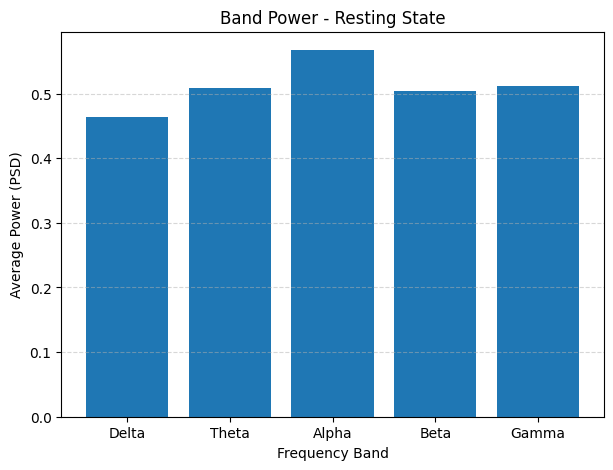

In [20]:
resting_band_power = {
    'Delta': resting[delta_cols].mean().mean(),
    'Theta': resting[theta_cols].mean().mean(),
    'Alpha': resting[alpha_cols].mean().mean(),
    'Beta' : resting[beta_cols].mean().mean(),
    'Gamma': resting[gamma_cols].mean().mean()
}

print("Band Power - Resting State")
print(resting_band_power)

# Plot bar chart
plt.figure(figsize=(7, 5))
plt.bar(resting_band_power.keys(), resting_band_power.values())
plt.title("Band Power - Resting State")
plt.xlabel("Frequency Band")
plt.ylabel("Average Power (PSD)")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


Memory Recall

Band Power - Memory Recall
{'Delta': np.float64(0.470224173226275), 'Theta': np.float64(0.5269649445992499), 'Alpha': np.float64(0.53338336133886), 'Beta': np.float64(0.5130184056676647), 'Gamma': np.float64(0.49028568548031143)}


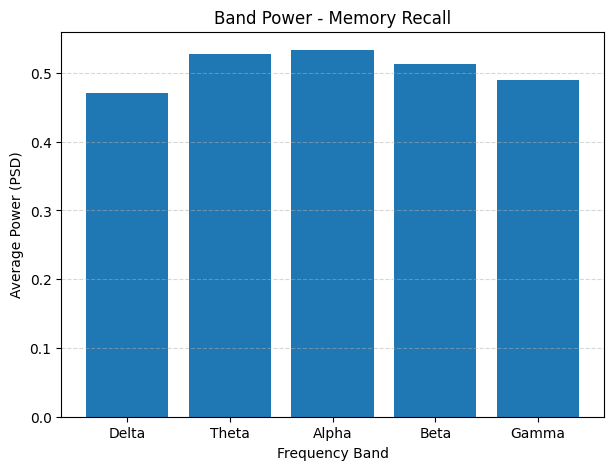

In [21]:
# Filter data kondisi
memory = df[df['Task'] == 'Memory Recall']

# Hitung band power
memory_band_power = {
    'Delta': memory[delta_cols].mean().mean(),
    'Theta': memory[theta_cols].mean().mean(),
    'Alpha': memory[alpha_cols].mean().mean(),
    'Beta' : memory[beta_cols].mean().mean(),
    'Gamma': memory[gamma_cols].mean().mean()
}

print("Band Power - Memory Recall")
print(memory_band_power)

# Plot bar chart
plt.figure(figsize=(7, 5))
plt.bar(memory_band_power.keys(), memory_band_power.values())
plt.title("Band Power - Memory Recall")
plt.xlabel("Frequency Band")
plt.ylabel("Average Power (PSD)")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


Arithmetic Calculation

Band Power - Arithmetic Calculation
{'Delta': np.float64(0.4411626835792499), 'Theta': np.float64(0.5687472900017501), 'Alpha': np.float64(0.5243144679538119), 'Beta': np.float64(0.5138345984331765), 'Gamma': np.float64(0.5045039272591146)}


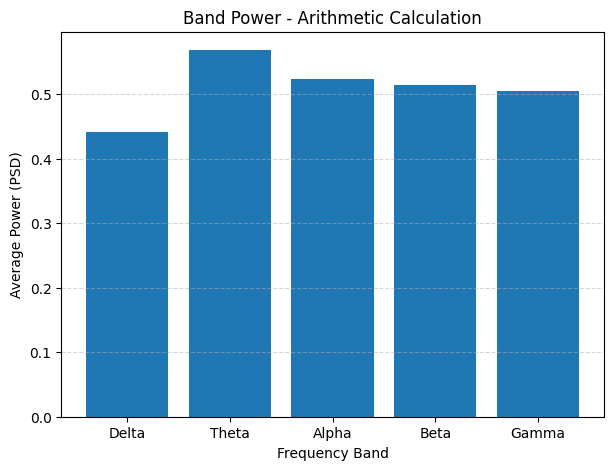

In [23]:
# Filter data kondisi
arith = df[df['Task'] == 'Arithmetic Calculation']

# Hitung band power
arith_band_power = {
    'Delta': arith[delta_cols].mean().mean(),
    'Theta': arith[theta_cols].mean().mean(),
    'Alpha': arith[alpha_cols].mean().mean(),
    'Beta' : arith[beta_cols].mean().mean(),
    'Gamma': arith[gamma_cols].mean().mean()
}

print("Band Power - Arithmetic Calculation")
print(arith_band_power)

# Plot bar chart
plt.figure(figsize=(7, 5))
plt.bar(arith_band_power.keys(), arith_band_power.values())
plt.title("Band Power - Arithmetic Calculation")
plt.xlabel("Frequency Band")
plt.ylabel("Average Power (PSD)")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


Visual Pattern Recognition

Band Power - Visual Pattern Recognition
{'Delta': np.float64(0.48767934312125), 'Theta': np.float64(0.4562546251703), 'Alpha': np.float64(0.5095347057362), 'Beta': np.float64(0.4789796795138058), 'Gamma': np.float64(0.49168747909641874)}


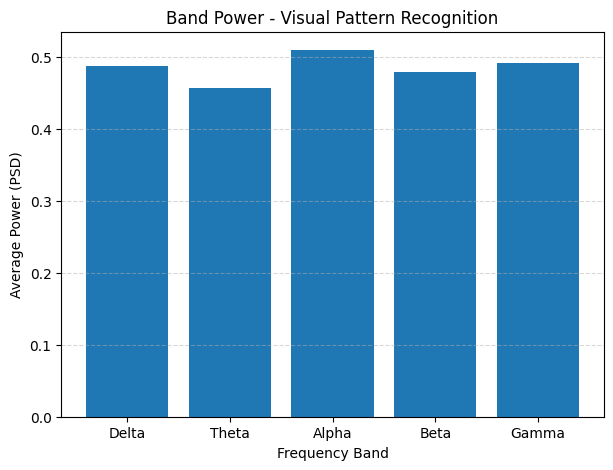

In [24]:
# Filter data kondisi
visual = df[df['Task'] == 'Visual Pattern Recognition']

# Hitung band power
visual_band_power = {
    'Delta': visual[delta_cols].mean().mean(),
    'Theta': visual[theta_cols].mean().mean(),
    'Alpha': visual[alpha_cols].mean().mean(),
    'Beta' : visual[beta_cols].mean().mean(),
    'Gamma': visual[gamma_cols].mean().mean()
}

print("Band Power - Visual Pattern Recognition")
print(visual_band_power)

# Plot bar chart
plt.figure(figsize=(7, 5))
plt.bar(visual_band_power.keys(), visual_band_power.values())
plt.title("Band Power - Visual Pattern Recognition")
plt.xlabel("Frequency Band")
plt.ylabel("Average Power (PSD)")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()
